# 03 – Approche semi-supervisée (ConvNeXt)

**Auteur :** Grégory CRESPIN  
**Projet :** Labellisez et appliquez des approches semi-supervisées en traitement d'images  
**Nom court :** BrainScanAI  
**Date :** 08/02/2026

Objectifs :
1. **Jeu fortement labellisé** : 100 images avec labels experts (normal/cancer). Split train/val/test.
2. **Jeu faiblement labellisé** : images avec labels issus du clustering (séparé, jamais mélangé pour l'évaluation).
3. Entraîner un CNN ConvNeXt d'abord sur le jeu faiblement labellisé, puis fine-tuner sur le jeu fortement labellisé.
4. Comparer : **supervisé** (uniquement fortement labellisé) vs **semi-supervisé** (faible puis fort).
5. Évaluer sur le **jeu de test fortement labellisé uniquement**, avec Accuracy, F1-score, Précision.

In [1]:
# ============================================
# IMPORTATIONS
# ============================================
# sys : permet de modifier le chemin de recherche des modules Python
import sys
# Path : manipulation des chemins de fichiers (Windows/Linux/Mac)
from pathlib import Path
# numpy : calculs numériques et tableaux
import numpy as np
# pandas : données structurées (DataFrames, CSV)
import pandas as pd
# matplotlib : graphiques et visualisations
import matplotlib.pyplot as plt
# torch : framework deep learning PyTorch
import torch
# torch.nn : couches de réseaux de neurones
import torch.nn as nn
# Dataset, DataLoader : chargement des données par batch
from torch.utils.data import Dataset, DataLoader
# models : modèles pré-entraînés (ConvNeXt) ; transforms : transformations d'images
from torchvision import models, transforms
# train_test_split : découpage train/test stratifié
from sklearn.model_selection import train_test_split
# Métriques de classification (accuracy, F1, précision, rapport, matrice de confusion)
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
# seaborn : graphiques statistiques (heatmaps, etc.)
import seaborn as sns
# tqdm : barres de progression
from tqdm import tqdm
from PIL import Image
# Ajouter le répertoire courant au path Python pour importer config
sys.path.insert(0, str(Path.cwd()))
# Fichier de config : chemins, hyperparamètres (LR, batch_size, etc.)
import config

## 1. Datasets et DataLoaders

In [2]:
# Transformations pour l'entraînement : incluent de l'augmentation de données
transform_train = transforms.Compose([
    # Redimensionner à 224x224
    transforms.Resize((config.RESIZE_FOR_MODEL, config.RESIZE_FOR_MODEL)),
    # RandomHorizontalFlip : retourner horizontalement aléatoirement (50% de chance)
    # Augmente artificiellement la taille du dataset
    transforms.RandomHorizontalFlip(),
    # RandomRotation : rotation aléatoire jusqu'à 10 degrés
    # Rend le modèle plus robuste aux petites rotations
    transforms.RandomRotation(10),
    # Convertir en tenseur et normaliser
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transformations pour l'évaluation : pas d'augmentation, juste redimensionnement et normalisation
transform_eval = transforms.Compose([
    transforms.Resize((config.RESIZE_FOR_MODEL, config.RESIZE_FOR_MODEL)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Classe Dataset : interface PyTorch pour charger des données
class ImageDataset(Dataset):
    def __init__(self, paths, labels, transform):
        """
        Initialise le dataset.
        
        Args:
            paths: liste des chemins vers les images
            labels: liste des labels correspondants
            transform: transformations à appliquer aux images
        """
        # Stocker les chemins, labels et transformations
        self.paths = list(paths)  # Convertir en liste si ce n'est pas déjà le cas
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        """Retourne le nombre d'images dans le dataset."""
        return len(self.paths)

    def __getitem__(self, i):
        """
        Charge et retourne une image et son label.
        
        Args:
            i: index de l'image à charger
        
        Returns:
            tuple (image_transformée, label)
        """
        # Ouvrir l'image depuis le chemin
        x = Image.open(self.paths[i]).convert("RGB")
        # Appliquer les transformations
        x = self.transform(x)
        # Récupérer le label correspondant
        y = self.labels[i]
        # Retourner le couple (image, label)
        return x, y

In [3]:
def collect_strong_data():
    """
    Collecte les chemins et labels des images fortement labellisées.
    Returns: tuple (paths, labels)
    """
    # Liste des chemins et liste des labels (indices 0=normal, 1=cancer)
    paths, labels = [], []
    # Parcourir chaque classe (normal, cancer)
    for cls in config.CLASSES:
        # Dossier de la classe (ex. datapic/avec_labels/normal)
        folder = config.LABELED_DIR / cls
        # Tous les fichiers .jpg du dossier
        for p in folder.glob("*.jpg"):
            # Chemin en chaîne pour compatibilité
            paths.append(str(p))
            # Index numérique : normal=0, cancer=1
            labels.append(config.CLASS_TO_IDX[cls])
    return paths, labels

# Récupérer toutes les images fortement labellisées
paths_strong, labels_strong = collect_strong_data()

# Split train / test : 20 % en test
# stratify : garder la même proportion normal/cancer dans train et test
paths_train, paths_test, y_train, y_test = train_test_split(
    paths_strong, labels_strong,
    test_size=config.TEST_SIZE,  # 0.2
    stratify=labels_strong,
    random_state=config.RANDOM_STATE
)

# Split train / validation : une partie du train pour la validation
# test_size : proportion du train utilisée en validation (pour avoir ~15 % du total)
paths_train, paths_val, y_train, y_val = train_test_split(
    paths_train, y_train,
    test_size=config.VAL_SIZE / (1 - config.TEST_SIZE),
    stratify=y_train,
    random_state=config.RANDOM_STATE
)

print("Fortement labellisé – train:", len(paths_train), "val:", len(paths_val), "test:", len(paths_test))

# Charger le jeu faiblement labellisé (labels issus du clustering, notebook 02)
df_weak = pd.read_csv(config.FEATURES_DIR / "weak_labels_from_clustering.csv")
# Liste des chemins des images faiblement labellisées
paths_weak = df_weak["path"].tolist()
# Labels faibles (0 ou 1) en entiers
labels_weak = df_weak["weak_label"].astype(int).tolist()
print("Faiblement labellisé:", len(paths_weak))

Fortement labellisé – train: 65 val: 15 test: 20
Faiblement labellisé: 1406


## 2. Modèle CNN (ConvNeXt fine-tunable)

In [4]:
def get_model(num_classes=2):
    """
    Crée un modèle ConvNeXt Base avec une couche de classification personnalisée.
    
    Args:
        num_classes: nombre de classes à prédire (2 : normal/cancer)
    
    Returns:
        Modèle ConvNeXt Base avec couche de classification à num_classes sorties
    """
    # Charger ConvNeXt Base pré-entraîné sur ImageNet
    model = models.convnext_base(weights=models.ConvNeXt_Base_Weights.IMAGENET1K_V1)
    
    # Remplacer la dernière couche (classifier = couche de classification)
    # Pour ConvNeXt, la couche finale est model.classifier qui est un Sequential
    # model.classifier[-1] : dernière couche du classifier (Linear)
    # model.classifier[-1].in_features : nombre de features en entrée de la couche finale
    # nn.Linear() : couche linéaire (matrice de poids + biais)
    # num_classes : nombre de sorties (2 pour notre classification binaire)
    model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
    
    return model

# Déterminer le device (GPU ou CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Fonction de perte : CrossEntropyLoss
# Utilisée pour la classification multi-classes
# Combine softmax + negative log likelihood
criterion = nn.CrossEntropyLoss()

## 3. Entraînement supervisé (uniquement fortement labellisé)

In [5]:
def train_epoch(model, loader, optimizer, device):
    """
    Entraîne le modèle pendant une époque (un passage complet sur le dataset).
    
    Args:
        model: modèle à entraîner
        loader: DataLoader qui fournit les batches d'images
        optimizer: optimiseur (Adam, SGD, etc.)
        device: GPU ou CPU
    
    Returns:
        Perte moyenne sur l'époque
    """
    # Mettre le modèle en mode entraînement
    # Active dropout, batch normalization en mode train, etc.
    model.train()
    
    # Initialiser la perte totale
    total_loss = 0
    
    # Parcourir chaque batch d'images
    for x, y in loader:
        # Déplacer les données sur le device (GPU si disponible)
        x, y = x.to(device), y.to(device)
        
        # Remettre à zéro les gradients de l'optimiseur
        # Sinon, les gradients s'accumulent entre les batches
        optimizer.zero_grad()
        
        # Forward pass : passer les images dans le modèle
        # out : prédictions du modèle (logits, pas encore probabilités)
        out = model(x)
        
        # Calculer la perte entre les prédictions et les vrais labels
        loss = criterion(out, y)
        
        # Backward pass : calculer les gradients
        # loss.backward() : propage l'erreur en arrière et calcule les gradients
        loss.backward()
        
        # Mettre à jour les poids du modèle avec l'optimiseur
        # optimizer.step() : utilise les gradients pour ajuster les poids
        optimizer.step()
        
        # Ajouter la perte de ce batch à la perte totale
        # .item() : extraire la valeur scalaire du tenseur
        total_loss += loss.item()
    
    # Retourner la perte moyenne (perte totale / nombre de batches)
    return total_loss / len(loader)

def evaluate(model, loader, device):
    """
    Évalue le modèle sur un dataset (validation ou test).
    
    Args:
        model: modèle à évaluer
        loader: DataLoader avec les données à évaluer
        device: GPU ou CPU
    
    Returns:
        tuple (vrais_labels, prédictions)
    """
    # Mettre le modèle en mode évaluation
    # Désactive dropout, batch norm en mode train, etc.
    model.eval()
    
    # Listes pour stocker les prédictions et les vrais labels
    preds, reals = [], []
    
    # Désactiver le calcul des gradients (plus rapide, moins de mémoire)
    with torch.no_grad():
        # Parcourir chaque batch
        for x, y in loader:
            # Déplacer sur le device
            x = x.to(device)
            
            # Forward pass
            out = model(x)
            
            # argmax(dim=1) : trouver l'index de la classe avec la plus haute probabilité
            # Exemple : si out = [[0.1, 0.9], [0.8, 0.2]], argmax donne [1, 0]
            # .cpu() : déplacer sur CPU
            # .numpy() : convertir en tableau numpy
            out = model(x).argmax(dim=1).cpu().numpy()
            
            # Ajouter les prédictions et les vrais labels aux listes
            preds.extend(out)  # extend() ajoute tous les éléments de la liste
            reals.extend(y.numpy())
    
    # Convertir en tableaux numpy pour faciliter les calculs
    return np.array(reals), np.array(preds)

In [6]:
# Créer les datasets PyTorch (train, validation, test)
ds_train = ImageDataset(paths_train, y_train, transform_train)
ds_val = ImageDataset(paths_val, y_val, transform_eval)
ds_test = ImageDataset(paths_test, y_test, transform_eval)

# DataLoaders : chargement par batch
# shuffle=True pour le train (mélange à chaque époque)
# shuffle=False pour val/test (ordre fixe pour reproductibilité)
# num_workers=0 : chargement dans le processus principal (évite soucis sous Windows)
loader_train = DataLoader(ds_train, batch_size=config.BATCH_SIZE_TRAIN, shuffle=True, num_workers=0)
loader_val = DataLoader(ds_val, batch_size=config.BATCH_SIZE_TRAIN, shuffle=False, num_workers=0)
loader_test = DataLoader(ds_test, batch_size=config.BATCH_SIZE_TRAIN, shuffle=False, num_workers=0)

# Modèle supervisé : ConvNeXt Base avec couche de classification à 2 classes
model_sup = get_model().to(device)

# Optimiseur Adam (learning rate défini dans config)
opt_sup = torch.optim.Adam(model_sup.parameters(), lr=config.LR)

# Historique : perte et accuracy de validation par époque
history_sup = {"loss": [], "val_acc": []}

# Boucle d'entraînement sur les données fortement labellisées uniquement
for epoch in range(config.EPOCHS_FINETUNE_STRONG):
    # Une époque = un passage sur tout le train
    loss = train_epoch(model_sup, loader_train, opt_sup, device)
    # Prédictions sur la validation
    yv, pv = evaluate(model_sup, loader_val, device)
    # Accuracy sur la validation
    acc = accuracy_score(yv, pv)
    history_sup["loss"].append(loss)
    history_sup["val_acc"].append(acc)
    # Affichage tous les 3 epochs
    if (epoch + 1) % 3 == 0:
        print(f"Epoch {epoch+1} loss={loss:.4f} val_acc={acc:.4f}")

# Évaluation finale sur le jeu de test (jamais vu à l'entraînement)
y_test_sup, pred_sup = evaluate(model_sup, loader_test, device)

print("\n--- Supervisé (test) ---")
print("Accuracy:", accuracy_score(y_test_sup, pred_sup))
print("F1 (macro):", f1_score(y_test_sup, pred_sup, average="macro"))
print("Précision (macro):", precision_score(y_test_sup, pred_sup, average="macro"))
print(classification_report(y_test_sup, pred_sup, target_names=config.CLASSES))

Epoch 3 loss=0.0599 val_acc=0.7333
Epoch 6 loss=0.0230 val_acc=0.8000
Epoch 9 loss=0.0050 val_acc=0.8000
Epoch 12 loss=0.0154 val_acc=0.8000
Epoch 15 loss=0.0014 val_acc=0.8000

--- Supervisé (test) ---
Accuracy: 1.0
F1 (macro): 1.0
Précision (macro): 1.0
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00        10
      cancer       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



## 4. Entraînement semi-supervisé (faible puis fort)

In [7]:
# Dataset et DataLoader pour les images faiblement labellisées (pseudo-labels du clustering)
ds_weak = ImageDataset(paths_weak, labels_weak, transform_train)
loader_weak = DataLoader(ds_weak, batch_size=config.BATCH_SIZE_TRAIN, shuffle=True, num_workers=0)

# Nouveau modèle (on ne réutilise pas model_sup)
model_ss = get_model().to(device)
opt_ss = torch.optim.Adam(model_ss.parameters(), lr=config.LR)

# Phase 1 : pré-entraînement sur les données faiblement labellisées
for epoch in range(config.EPOCHS_PRETRAIN_WEAK):
    loss = train_epoch(model_ss, loader_weak, opt_ss, device)
    if (epoch + 1) % 2 == 0:
        print(f"Phase faible Epoch {epoch+1} loss={loss:.4f}")

# Phase 2 : fine-tuning sur les données fortement labellisées (vrais labels)
# Nouvel optimiseur avec learning rate réduit pour un réglage plus fin
opt_ss = torch.optim.Adam(model_ss.parameters(), lr=config.LR * 0.5)
for epoch in range(config.EPOCHS_FINETUNE_STRONG):
    loss = train_epoch(model_ss, loader_train, opt_ss, device)
    yv, pv = evaluate(model_ss, loader_val, device)
    acc = accuracy_score(yv, pv)
    if (epoch + 1) % 3 == 0:
        print(f"Phase fort Epoch {epoch+1} loss={loss:.4f} val_acc={acc:.4f}")

# Évaluation sur le même jeu de test que le modèle supervisé
y_test_ss, pred_ss = evaluate(model_ss, loader_test, device)
print("\n--- Semi-supervisé (test) ---")
print("Accuracy:", accuracy_score(y_test_ss, pred_ss))
print("F1 (macro):", f1_score(y_test_ss, pred_ss, average="macro"))
print("Précision (macro):", precision_score(y_test_ss, pred_ss, average="macro"))
print(classification_report(y_test_ss, pred_ss, target_names=config.CLASSES))

Phase faible Epoch 2 loss=0.1074
Phase faible Epoch 4 loss=0.0843
Phase fort Epoch 3 loss=0.1070 val_acc=0.8667
Phase fort Epoch 6 loss=0.0409 val_acc=0.8667
Phase fort Epoch 9 loss=0.0225 val_acc=0.8667
Phase fort Epoch 12 loss=0.0077 val_acc=0.8667
Phase fort Epoch 15 loss=0.0019 val_acc=0.8667

--- Semi-supervisé (test) ---
Accuracy: 0.95
F1 (macro): 0.949874686716792
Précision (macro): 0.9545454545454546
              precision    recall  f1-score   support

      normal       0.91      1.00      0.95        10
      cancer       1.00      0.90      0.95        10

    accuracy                           0.95        20
   macro avg       0.95      0.95      0.95        20
weighted avg       0.95      0.95      0.95        20



## 5. Validation croisée 5-fold

Pour une estimation plus robuste des performances, on utilise une validation croisée stratifiée à 5 folds sur les 100 images fortement labellisées. Pour chaque fold :
- **Train+Val** = 80 % des données (4 folds)
- **Test** = 20 % (1 fold, jamais vu à l'entraînement)

On entraîne les deux approches (supervisé et semi-supervisé) sur chaque fold et on rapporte la **moyenne ± écart-type** des métriques.

In [8]:
# ============================================
# VALIDATION CROISÉE 5-FOLD
# ============================================
from sklearn.model_selection import StratifiedKFold
N_FOLDS=config.N_FOLDS
# Subdivision stratifiée des indices (même proportion normal/cancer dans chaque fold)
kfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=config.RANDOM_STATE)

# Stocker les métriques par fold pour supervisé et semi-supervisé
metrics_sup = {"accuracy": [], "f1": [], "precision": []}
metrics_ss = {"accuracy": [], "f1": [], "precision": []}

# Listes pour accumuler les vrais labels et probabilités (classe 1) sur tous les folds
y_true_cv_list = []       # vrais labels (communs aux deux approches)
y_proba_cv_sup_list = []  # proba classe 1 pour supervisé
y_proba_cv_ss_list = []   # proba classe 1 pour semi-supervisé

# Chemins et labels en listes (pour indexation par fold)
paths_strong_list = np.array(paths_strong)
labels_strong_list = np.array(labels_strong)

from sklearn.metrics import roc_curve, auc

def get_proba_predictions(model, loader, device):
    """Retourne (y_true, y_proba_classe1) pour un modèle et un loader."""
    model.eval()
    y_proba, y_true = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x)
            probs = torch.softmax(out, dim=1)
            y_proba.extend(probs[:, 1].cpu().numpy())
            y_true.extend(y.numpy())
    return np.array(y_true), np.array(y_proba)


print("Démarrage de la validation croisée 5-fold...\n")

for fold, (train_val_idx, test_idx) in enumerate(kfold.split(paths_strong_list, labels_strong_list)):
    print(f"--- Fold {fold + 1}/{N_FOLDS} ---")
    
    # Séparer train+val et test pour ce fold
    paths_train_val = paths_strong_list[train_val_idx].tolist()
    y_train_val = labels_strong_list[train_val_idx].tolist()
    paths_test_fold = paths_strong_list[test_idx].tolist()
    y_test_fold = labels_strong_list[test_idx].tolist()
    
    # Split train / val à l'intérieur des 80 % (stratifié)
    paths_train_f, paths_val_f, y_train_f, y_val_f = train_test_split(
        paths_train_val, y_train_val,
        test_size=config.VAL_SIZE / (1 - 1/N_FOLDS),  # ~15 % de l'ensemble en val
        stratify=y_train_val,
        random_state=config.RANDOM_STATE
    )
    
    # Datasets et DataLoaders pour ce fold
    ds_train_f = ImageDataset(paths_train_f, y_train_f, transform_train)
    ds_val_f = ImageDataset(paths_val_f, y_val_f, transform_eval)
    ds_test_f = ImageDataset(paths_test_fold, y_test_fold, transform_eval)
    loader_train_f = DataLoader(ds_train_f, batch_size=config.BATCH_SIZE_TRAIN, shuffle=True, num_workers=0)
    loader_val_f = DataLoader(ds_val_f, batch_size=config.BATCH_SIZE_TRAIN, shuffle=False, num_workers=0)
    loader_test_f = DataLoader(ds_test_f, batch_size=config.BATCH_SIZE_TRAIN, shuffle=False, num_workers=0)
    
    # ---- Approche supervisée ----
    model_sup_f = get_model().to(device)
    opt_sup_f = torch.optim.Adam(model_sup_f.parameters(), lr=config.LR)
    for _ in range(config.EPOCHS_FINETUNE_STRONG):
        train_epoch(model_sup_f, loader_train_f, opt_sup_f, device)
    y_true_f, y_proba_sup_f = get_proba_predictions(model_sup_f, loader_test_f, device)
    pred_sup_f = (y_proba_sup_f >= 0.5).astype(int)
    metrics_sup["accuracy"].append(accuracy_score(y_true_f, pred_sup_f))
    y_true_cv_list.append(y_true_f)
    y_proba_cv_sup_list.append(y_proba_sup_f)
    metrics_sup["f1"].append(f1_score(y_true_f, pred_sup_f, average="macro"))
    metrics_sup["precision"].append(precision_score(y_true_f, pred_sup_f, average="macro"))
    
    # ---- Approche semi-supervisée ----
    model_ss_f = get_model().to(device)
    opt_ss_f = torch.optim.Adam(model_ss_f.parameters(), lr=config.LR)
    for _ in range(config.EPOCHS_PRETRAIN_WEAK):
        train_epoch(model_ss_f, loader_weak, opt_ss_f, device)
    opt_ss_f = torch.optim.Adam(model_ss_f.parameters(), lr=config.LR * 0.5)
    for _ in range(config.EPOCHS_FINETUNE_STRONG):
        train_epoch(model_ss_f, loader_train_f, opt_ss_f, device)
    _, y_proba_ss_f = get_proba_predictions(model_ss_f, loader_test_f, device)
    pred_ss_f = (y_proba_ss_f >= 0.5).astype(int)
    metrics_ss["accuracy"].append(accuracy_score(y_true_f, pred_ss_f))
    y_proba_cv_ss_list.append(y_proba_ss_f)
    metrics_ss["f1"].append(f1_score(y_true_f, pred_ss_f, average="macro"))
    metrics_ss["precision"].append(precision_score(y_true_f, pred_ss_f, average="macro"))

# Résumé : moyenne ± écart-type sur les 5 folds
print("\n" + "=" * 60)
print("RÉSULTATS 5-FOLD CROSS-VALIDATION (moyenne ± std)")
print("=" * 60)
print(f"\nSupervisé (fort uniquement) :")
print(f"  Accuracy : {np.mean(metrics_sup['accuracy']):.4f} ± {np.std(metrics_sup['accuracy']):.4f}")
print(f"  F1 (macro) : {np.mean(metrics_sup['f1']):.4f} ± {np.std(metrics_sup['f1']):.4f}")
print(f"  Précision (macro) : {np.mean(metrics_sup['precision']):.4f} ± {np.std(metrics_sup['precision']):.4f}")
print(f"\nSemi-supervisé (faible puis fort) :")
print(f"  Accuracy : {np.mean(metrics_ss['accuracy']):.4f} ± {np.std(metrics_ss['accuracy']):.4f}")
print(f"  F1 (macro) : {np.mean(metrics_ss['f1']):.4f} ± {np.std(metrics_ss['f1']):.4f}")
print(f"  Précision (macro) : {np.mean(metrics_ss['precision']):.4f} ± {np.std(metrics_ss['precision']):.4f}")

y_true_cv = np.concatenate(y_true_cv_list)
y_proba_cv_sup = np.concatenate(y_proba_cv_sup_list)
y_proba_cv_ss = np.concatenate(y_proba_cv_ss_list)


Démarrage de la validation croisée 5-fold...

--- Fold 1/5 ---
--- Fold 2/5 ---
--- Fold 3/5 ---
--- Fold 4/5 ---
--- Fold 5/5 ---

RÉSULTATS 5-FOLD CROSS-VALIDATION (moyenne ± std)

Supervisé (fort uniquement) :
  Accuracy : 0.9200 ± 0.0600
  F1 (macro) : 0.9198 ± 0.0602
  Précision (macro) : 0.9232 ± 0.0593

Semi-supervisé (faible puis fort) :
  Accuracy : 0.9400 ± 0.0374
  F1 (macro) : 0.9395 ± 0.0378
  Précision (macro) : 0.9485 ± 0.0308


## 6. Comparaison et visualisation

In [9]:
# DataFrame pour comparer les deux approches (supervisé vs semi-supervisé)
comparison_cv = pd.DataFrame({
    "Approche": ["Supervisé (fort uniquement)", "Semi-supervisé (faible puis fort)"],
    "Accuracy": [
        f"{np.mean(metrics_sup['accuracy']):.4f} ± {np.std(metrics_sup['accuracy']):.4f}",
        f"{np.mean(metrics_ss['accuracy']):.4f} ± {np.std(metrics_ss['accuracy']):.4f}",
    ],
    "F1 (macro)": [
        f"{np.mean(metrics_sup['f1']):.4f} ± {np.std(metrics_sup['f1']):.4f}",
        f"{np.mean(metrics_ss['f1']):.4f} ± {np.std(metrics_ss['f1']):.4f}",
    ],
    "Précision (macro)": [
        f"{np.mean(metrics_sup['precision']):.4f} ± {np.std(metrics_sup['precision']):.4f}",
        f"{np.mean(metrics_ss['precision']):.4f} ± {np.std(metrics_ss['precision']):.4f}",
    ],
})
print("Résultats 5-fold (moyenne ± écart-type) :")
print(comparison_cv.to_string(index=False))

Résultats 5-fold (moyenne ± écart-type) :
                         Approche        Accuracy      F1 (macro) Précision (macro)
      Supervisé (fort uniquement) 0.9200 ± 0.0600 0.9198 ± 0.0602   0.9232 ± 0.0593
Semi-supervisé (faible puis fort) 0.9400 ± 0.0374 0.9395 ± 0.0378   0.9485 ± 0.0308


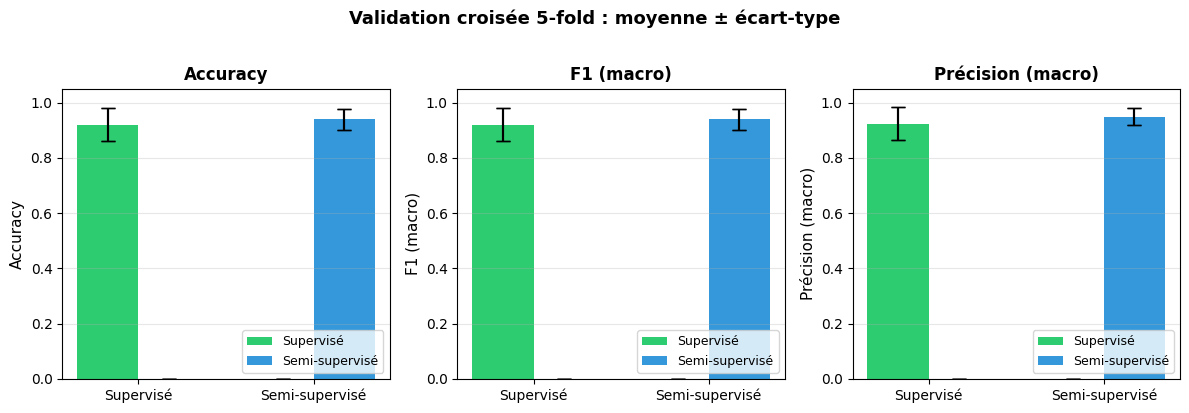

In [10]:
# -----------------------------------------------------------------------------
# Barres d'erreur – Comparaison Supervisé vs Semi-supervisé
# -----------------------------------------------------------------------------
# Un graphique par métrique (Accuracy, F1, Précision) avec barres et barres d'erreur (écart-type).

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

metriques = ["accuracy", "f1", "precision"]
titres = ["Accuracy", "F1 (macro)", "Précision (macro)"]
x = np.arange(2)  # Supervisé, Semi-supervisé
largeur = 0.35

for i, (met, titre) in enumerate(zip(metriques, titres)):
    means_sup = np.mean(metrics_sup[met])
    std_sup = np.std(metrics_sup[met])
    means_ss = np.mean(metrics_ss[met])
    std_ss = np.std(metrics_ss[met])
    axes[i].bar(x - largeur/2, [means_sup, 0], largeur, yerr=[std_sup, 0], capsize=5, label="Supervisé", color="#2ecc71")
    axes[i].bar(x + largeur/2, [0, means_ss], largeur, yerr=[0, std_ss], capsize=5, label="Semi-supervisé", color="#3498db")
    # Réafficher les vraies valeurs (les barres à 0 étaient pour la légende)
    axes[i].bar(x - largeur/2, [means_sup, 0], largeur, yerr=[std_sup, 0], capsize=5, color="#2ecc71")
    axes[i].bar(x + largeur/2, [0, means_ss], largeur, yerr=[0, std_ss], capsize=5, color="#3498db")
    axes[i].set_ylabel(titre, fontsize=11)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(["Supervisé", "Semi-supervisé"])
    axes[i].set_title(titre, fontsize=12, fontweight="bold")
    axes[i].set_ylim(0, 1.05)
    axes[i].legend(loc="lower right", fontsize=9)
    axes[i].grid(axis="y", alpha=0.3)

plt.suptitle("Validation croisée 5-fold : moyenne ± écart-type", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

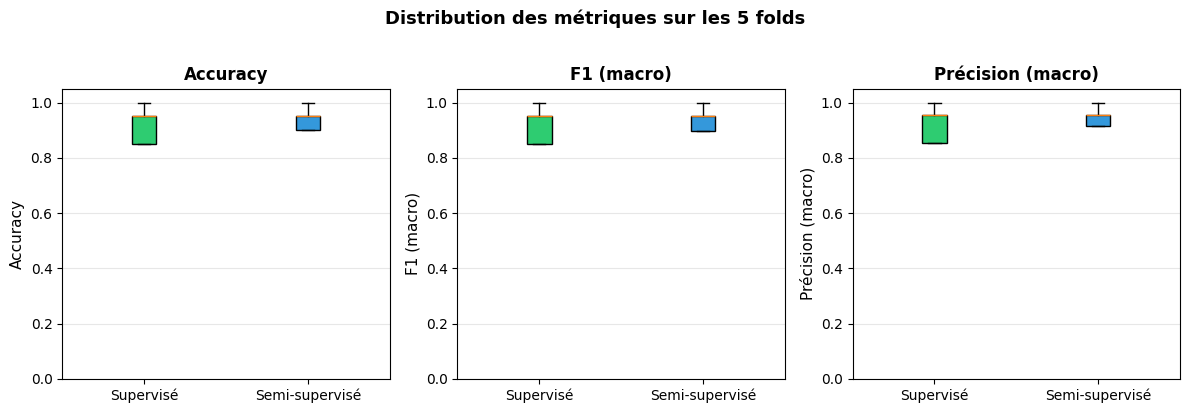

In [15]:
# -----------------------------------------------------------------------------
# Box plots – Distribution des 5 folds par approche et par métrique
# -----------------------------------------------------------------------------
# Montre la variabilité des métriques sur les 5 folds.

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, (met, titre) in enumerate(zip(metriques, titres)):
    data = [metrics_sup[met], metrics_ss[met]]
    bp = axes[i].boxplot(data, tick_labels=["Supervisé", "Semi-supervisé"], patch_artist=True)
    bp["boxes"][0].set_facecolor("#2ecc71")
    bp["boxes"][1].set_facecolor("#3498db")
    axes[i].set_ylabel(titre, fontsize=11)
    axes[i].set_title(titre, fontsize=12, fontweight="bold")
    axes[i].set_ylim(0, 1.05)
    axes[i].grid(axis="y", alpha=0.3)

plt.suptitle("Distribution des métriques sur les 5 folds", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

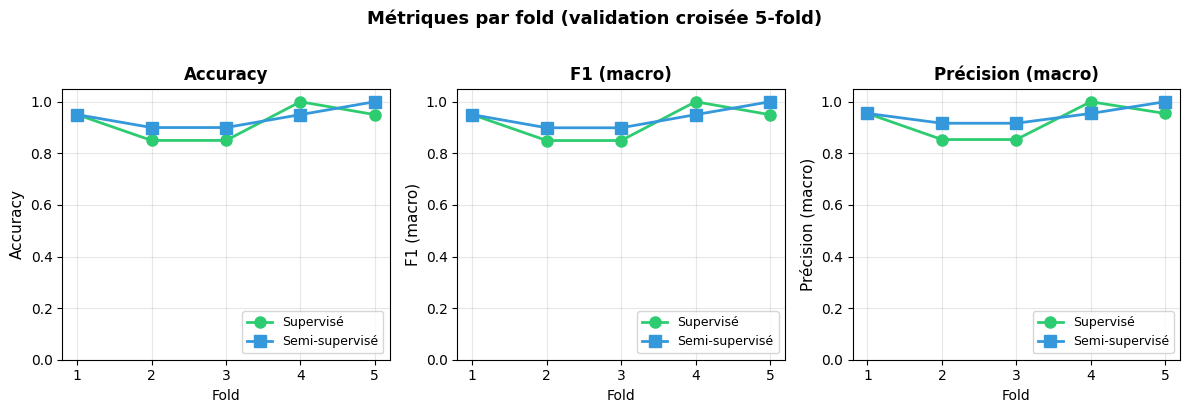

In [12]:
# -----------------------------------------------------------------------------
# Évolution des métriques par fold (courbes)
# -----------------------------------------------------------------------------
# Un graphique avec 3 courbes : Accuracy, F1, Précision en fonction du numéro de fold.
# Deux lignes par métrique : Supervisé et Semi-supervisé.

folds = np.arange(1, N_FOLDS + 1)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, (met, titre) in enumerate(zip(metriques, titres)):
    axes[i].plot(folds, metrics_sup[met], "o-", color="#2ecc71", linewidth=2, markersize=8, label="Supervisé")
    axes[i].plot(folds, metrics_ss[met], "s-", color="#3498db", linewidth=2, markersize=8, label="Semi-supervisé")
    axes[i].set_xlabel("Fold", fontsize=10)
    axes[i].set_ylabel(titre, fontsize=11)
    axes[i].set_title(titre, fontsize=12, fontweight="bold")
    axes[i].set_xticks(folds)
    axes[i].set_ylim(0, 1.05)
    axes[i].legend(loc="lower right", fontsize=9)
    axes[i].grid(alpha=0.3)

plt.suptitle("Métriques par fold (validation croisée 5-fold)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

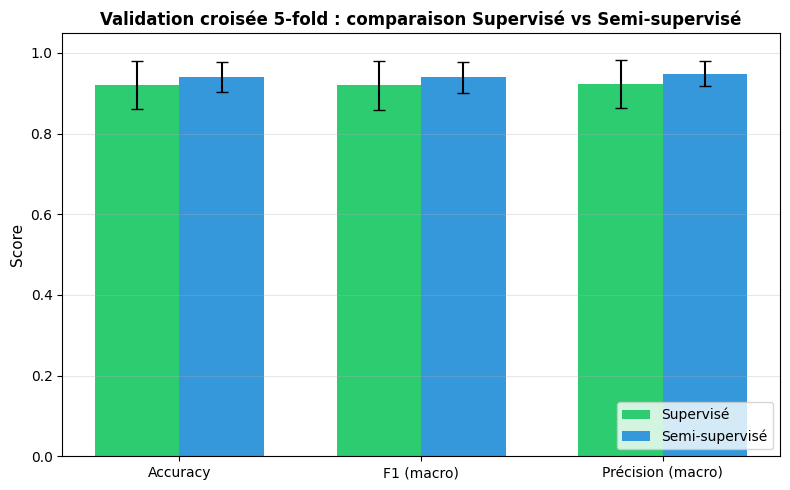

In [13]:
# -----------------------------------------------------------------------------
# Un seul graphique regroupant les 3 métriques en barres groupées
# -----------------------------------------------------------------------------
# Barres groupées : pour chaque approche, 3 barres (Accuracy, F1, Précision).

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(3)  # Accuracy, F1, Précision
largeur = 0.35

means_sup = [np.mean(metrics_sup["accuracy"]), np.mean(metrics_sup["f1"]), np.mean(metrics_sup["precision"])]
std_sup = [np.std(metrics_sup["accuracy"]), np.std(metrics_sup["f1"]), np.std(metrics_sup["precision"])]
means_ss = [np.mean(metrics_ss["accuracy"]), np.mean(metrics_ss["f1"]), np.mean(metrics_ss["precision"])]
std_ss = [np.std(metrics_ss["accuracy"]), np.std(metrics_ss["f1"]), np.std(metrics_ss["precision"])]

ax.bar(x - largeur/2, means_sup, largeur, yerr=std_sup, capsize=4, label="Supervisé", color="#2ecc71")
ax.bar(x + largeur/2, means_ss, largeur, yerr=std_ss, capsize=4, label="Semi-supervisé", color="#3498db")

ax.set_ylabel("Score", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(["Accuracy", "F1 (macro)", "Précision (macro)"])
ax.set_title("Validation croisée 5-fold : comparaison Supervisé vs Semi-supervisé", fontsize=12, fontweight="bold")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

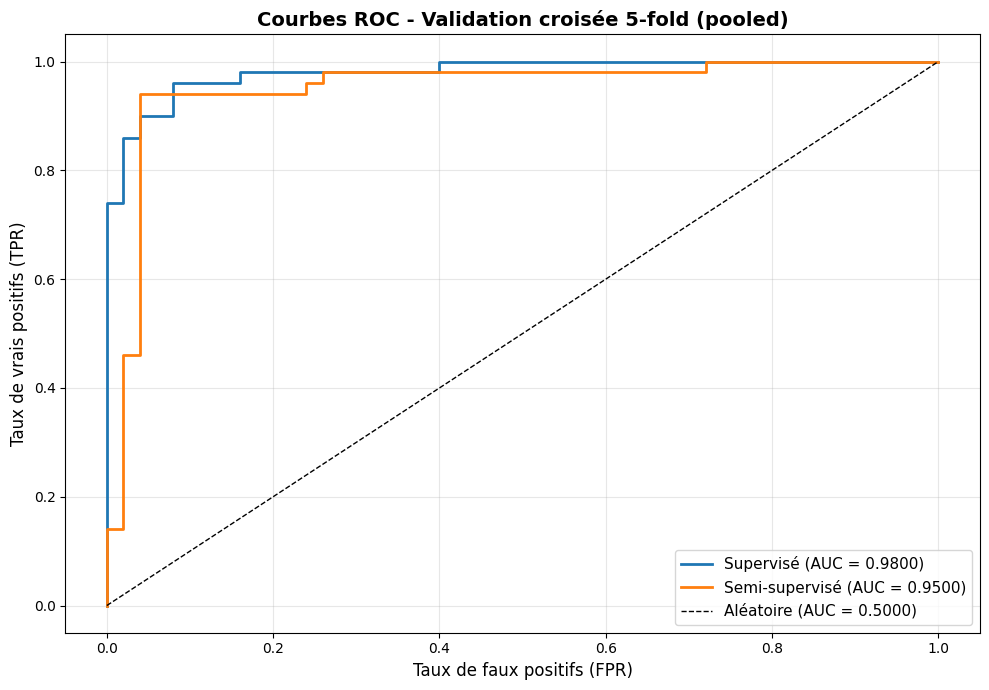


📊 Métriques (CV 5-fold) avec AUC :
                         Approche        Accuracy      F1 (macro) Précision (macro)  AUC (CV pooled)
      Supervisé (fort uniquement) 0.9200 ± 0.0600 0.9198 ± 0.0602   0.9232 ± 0.0593             0.98
Semi-supervisé (faible puis fort) 0.9400 ± 0.0374 0.9395 ± 0.0378   0.9485 ± 0.0308             0.95


In [14]:
# ============================================
# COURBES ROC ET AUC
# ============================================

from sklearn.metrics import roc_curve, auc

# Courbes ROC à partir des probabilités poolées (CV)
fpr_sup, tpr_sup, _ = roc_curve(y_true_cv, y_proba_cv_sup)
fpr_ss, tpr_ss, _ = roc_curve(y_true_cv, y_proba_cv_ss)
auc_sup = auc(fpr_sup, tpr_sup)
auc_ss = auc(fpr_ss, tpr_ss)

# Graphique
plt.figure(figsize=(10, 7))
plt.plot(fpr_sup, tpr_sup, label=f'Supervisé (AUC = {auc_sup:.4f})', linewidth=2)
plt.plot(fpr_ss, tpr_ss, label=f'Semi-supervisé (AUC = {auc_ss:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC = 0.5000)', linewidth=1)
plt.xlabel('Taux de faux positifs (FPR)', fontsize=12)
plt.ylabel('Taux de vrais positifs (TPR)', fontsize=12)
plt.title('Courbes ROC - Validation croisée 5-fold (pooled)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Tableau avec AUC issues de la validation croisée
print("\n📊 Métriques (CV 5-fold) avec AUC :")
comparison_roc_cv = pd.DataFrame({
    "Approche": ["Supervisé (fort uniquement)", "Semi-supervisé (faible puis fort)"],
    "Accuracy": [
        f"{np.mean(metrics_sup['accuracy']):.4f} ± {np.std(metrics_sup['accuracy']):.4f}",
        f"{np.mean(metrics_ss['accuracy']):.4f} ± {np.std(metrics_ss['accuracy']):.4f}",
    ],
    "F1 (macro)": [
        f"{np.mean(metrics_sup['f1']):.4f} ± {np.std(metrics_sup['f1']):.4f}",
        f"{np.mean(metrics_ss['f1']):.4f} ± {np.std(metrics_ss['f1']):.4f}",
    ],
    "Précision (macro)": [
        f"{np.mean(metrics_sup['precision']):.4f} ± {np.std(metrics_sup['precision']):.4f}",
        f"{np.mean(metrics_ss['precision']):.4f} ± {np.std(metrics_ss['precision']):.4f}",
    ],
    "AUC (CV pooled)": [round(auc_sup, 4), round(auc_ss, 4)],
})
print(comparison_roc_cv.to_string(index=False))

## Conclusion

- Jeu de test fortement labellisé **jamais vu** à l'entraînement.
- Métriques : Accuracy, F1 (macro), Précision (macro) — F1 pertinent en cas de déséquilibre.
- Comparaison supervisé vs semi-supervisé documentée.
- Jeu faiblement labellisé conservé **séparé** du jeu fortement labellisé.